# EDA on Retail Sales Data

# Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to identify sales patterns, customer behaviour, product performance, and actionable business insights.

# Tech Stack
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [2]:
#Import Libraries
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
#Load Dataset
df= pd.read_csv("realistic_e_commerce_sales_data.csv") 
df.head()

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
0,CUST0268,Male,North,NaN,Monitor,Electronics,300.0,5,1500,13.31,Returned,2023-12-08
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,In Transit,2023-04-09
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,Returned,2023-08-28
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,Delivered,2023-01-18
4,CUST0173,Female,South,NaN,Laptop,Electronics,1500.0,3,4500,5.40,Delivered,2023-01-19


In [8]:
#Initial Dataset Inspection:

%matplotlib inline
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1000, 12)

Column Names:
Index(['Customer ID', 'Gender', 'Region', 'Age', 'Product Name', 'Category',
       'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee',
       'Shipping Status', 'Order Date'],
      dtype='object')

Data Types:
Customer ID         object
Gender              object
Region              object
Age                float64
Product Name        object
Category            object
Unit Price         float64
Quantity             int64
Total Price          int64
Shipping Fee       float64
Shipping Status     object
Order Date          object
dtype: object

Missing Values:
Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64


## Initial Observation

The dataset contains 1,000 records and 12 columns. It includes customer demographic information, product details, sales information, shipping details, and order dates.

Missing values are present in the Age, Region, and Shipping Status columns. These missing values need to be handled before performing further analysis.

In [9]:
#Check Duplicate Values
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
#DATA CLEANING 
#Handle Missing Values
# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Region values with mode
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])

# Fill missing Shipping Status values with mode
df["Shipping Status"] = df["Shipping Status"].fillna(
    df["Shipping Status"].mode()[0]
)
print(df.isnull().sum())

Customer ID        0
Gender             0
Region             0
Age                0
Product Name       0
Category           0
Unit Price         0
Quantity           0
Total Price        0
Shipping Fee       0
Shipping Status    0
Order Date         0
dtype: int64


## Data Cleaning Observation

Missing values were handled before analysis.

- Missing Age values were replaced using the median age.
- Missing Region values were replaced using the most frequent region.
- Missing Shipping Status values were replaced using the most frequent shipping status.

After data cleaning, the dataset contains no missing values.

In [11]:
#Descriptive Statistics
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
statistics = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Mode": df[numerical_columns].mode().iloc[0],
    "Standard Deviation": df[numerical_columns].std()
})
statistics

,Mean,Median,Mode,Standard Deviation
Age,46.926000,49.000,49.00,14.257061
Unit Price,457.703777,200.000,300.00,537.231434
Quantity,3.008000,3.000,3.00,1.404246
Total Price,1346.600000,600.000,200.00,1834.037877
Shipping Fee,12.416390,12.315,9.26,4.412185


## Descriptive Statistics Observation

Descriptive statistics were calculated for all numerical columns, including Age, Unit Price, Quantity, Total Price, and Shipping Fee.

The analysis helps understand the central tendency and variability of customer purchases and product prices.

## TIME SERIES ANALYSIS

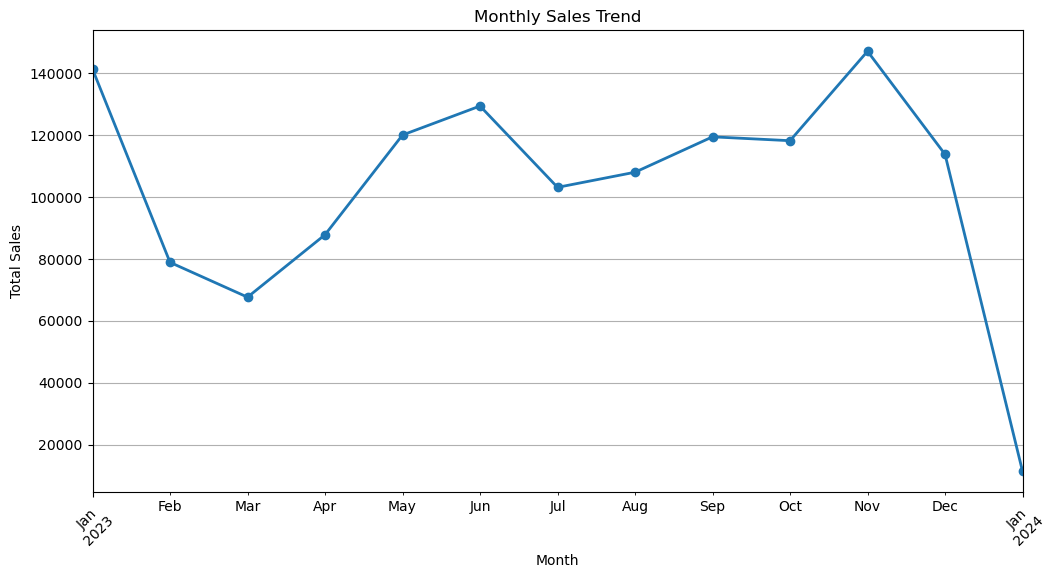

In [12]:
#Monthly Sales Trend
df["Month"] = df["Order Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Total Price"].sum()
plt.figure(figsize=(12, 6))
monthly_sales.plot(
    marker="o",
    linewidth=2
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Monthly Sales Trend Observation

The monthly sales trend shows fluctuations in sales throughout the year.

The highest sales were observed during November 2023, while some months recorded comparatively lower sales.

The final month, January 2024, contains significantly lower sales because the dataset appears to include only a partial period for that month.

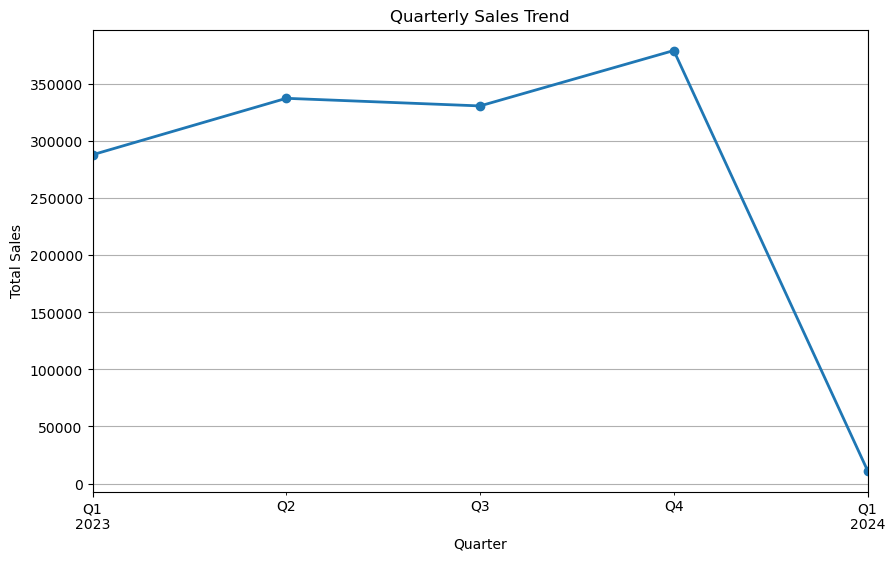

In [13]:
#Quarterly Sales Trend
df["Quarter"] = df["Order Date"].dt.to_period("Q")

quarterly_sales = df.groupby("Quarter")["Total Price"].sum()
plt.figure(figsize=(10, 6))
quarterly_sales.plot(
    marker="o",
    linewidth=2
)
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# Quarterly Sales Trend Observation

Quarterly analysis shows that Q4 of 2023 generated the highest sales revenue.

This indicates stronger customer purchasing activity during the final quarter of the year, possibly due to seasonal demand and promotional events.

## CUSTOMER DEMOGRAPHICS ANALYSIS

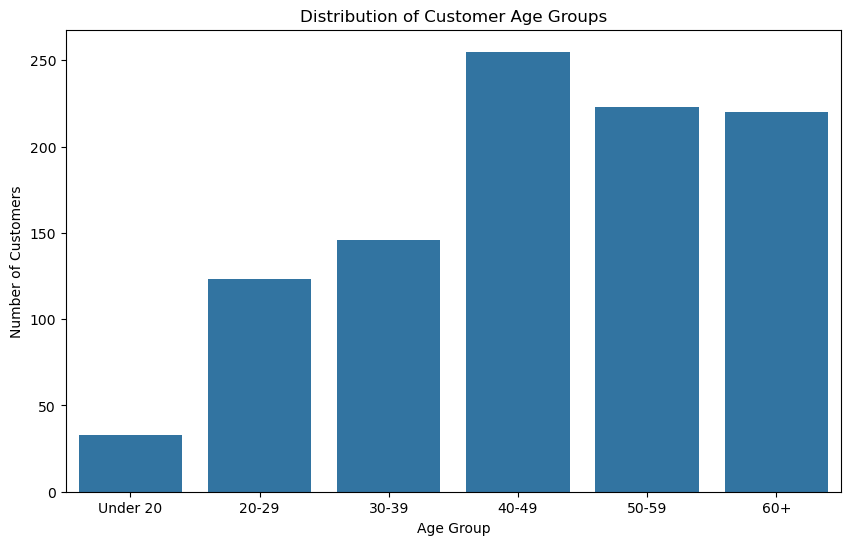

In [14]:
#Age Group Distribution
bins = [0, 20, 30, 40, 50, 60, 100]

labels = [
    "Under 20",
    "20-29",
    "30-39",
    "40-49",
    "50-59",
    "60+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Age Group"
)

plt.title("Distribution of Customer Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

## Customer Age Group Observation

The largest customer group belongs to the 40–49 age category.

Customers between 40 and 59 years represent a significant portion of the customer base. This suggests that marketing strategies can be targeted toward these age groups.

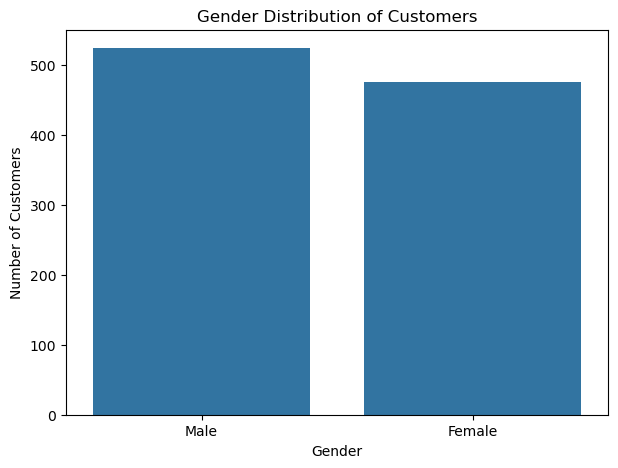

In [15]:
#Gender Breakdown
gender_count = df["Gender"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_count.index,
    y=gender_count.values
)

plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## Gender Distribution Observation

The dataset contains a relatively balanced distribution of male and female customers.

Male customers are slightly higher in number compared to female customers.

## PRODUCT ANALYSIS

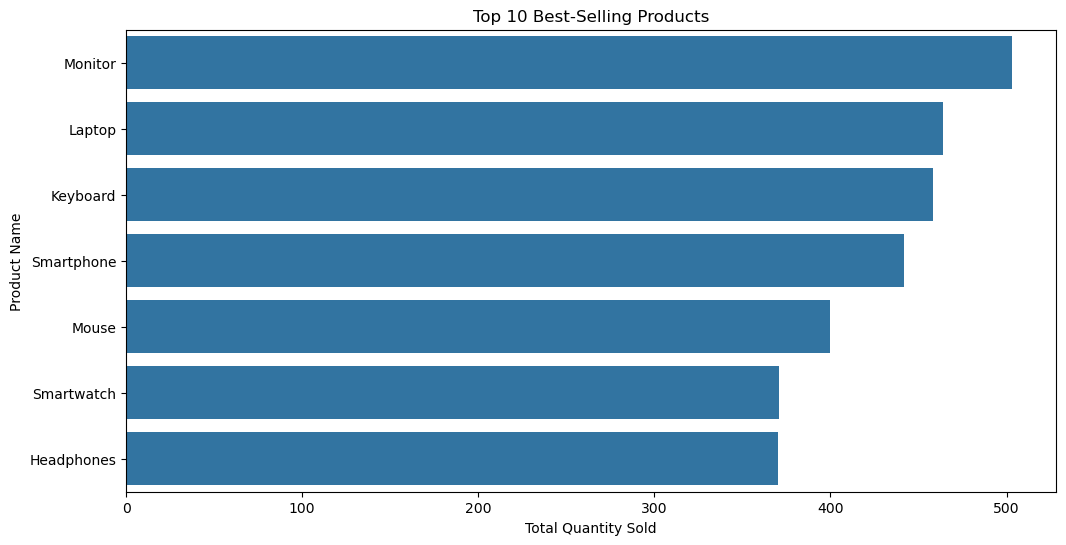

In [16]:
#Top 10 Best-Selling Products
top_products = (
    df.groupby("Product Name")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Name")

plt.show()

## Product Analysis Observation

The Monitor is the best-selling product based on total quantity sold.

Laptops, Keyboards, Smartphones, and other technology products also show strong customer demand.

This information can help the business prioritize inventory management for high-demand products.

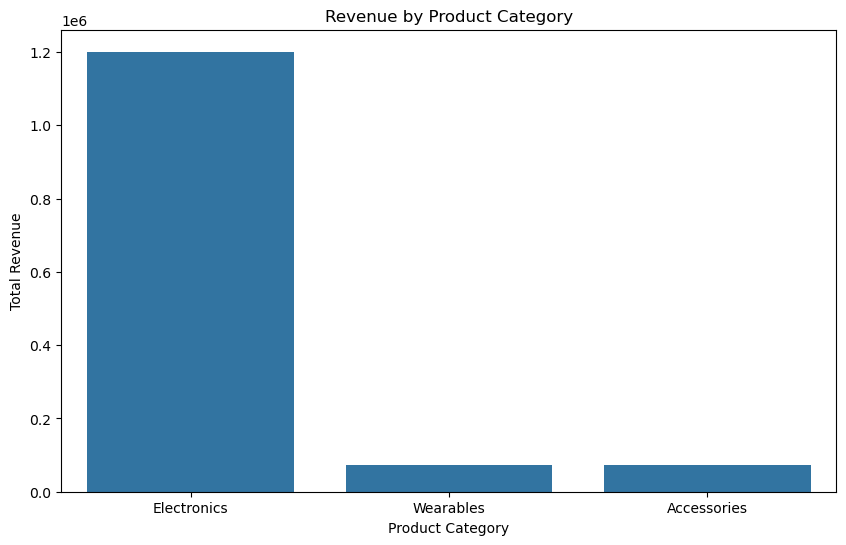

In [17]:
#Revenue by Product Category
category_revenue = (
    df.groupby("Category")["Total Price"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.show()

## Revenue by Category Observation

The Electronics category generates the highest revenue by a large margin.

Wearables and Accessories contribute significantly less revenue compared to Electronics.

The business should continue focusing on Electronics while exploring strategies to improve sales in other categories.

## CORRELATION HEATMAP

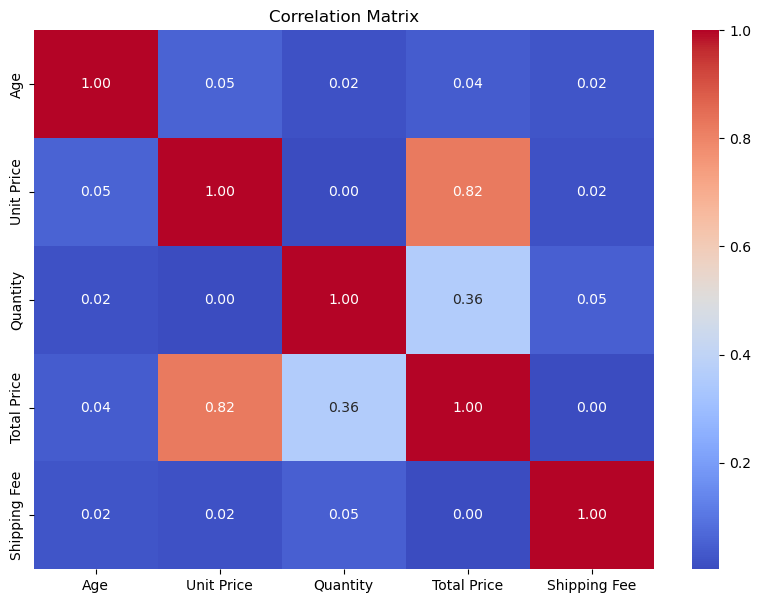

In [18]:
numerical_data = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 7))

sns.heatmap(
    numerical_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Correlation Analysis Observation

The correlation heatmap helps identify relationships between numerical variables.

Total Price shows a relationship with Unit Price and Quantity because the total purchase value is influenced by both product price and the number of products purchased.

Correlation analysis helps identify important variables affecting sales performance.

## Region-wise Average Customer Spending

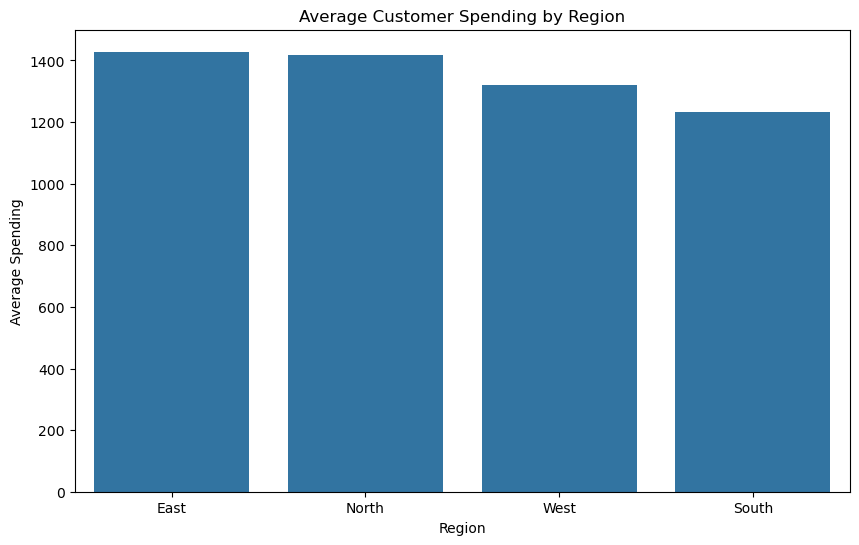

In [19]:
region_spending = (
    df.groupby("Region")["Total Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_spending.index,
    y=region_spending.values
)

plt.title("Average Customer Spending by Region")
plt.xlabel("Region")
plt.ylabel("Average Spending")

plt.show()

## Insight

The East region has the highest average customer spending, followed closely by the North region.

Interestingly, a region with fewer transactions may still generate higher average spending per customer.

This insight can help the business create region-specific marketing and premium product strategies.

## Final Conclusion:

# Conclusion and Business Recommendations

Based on the Exploratory Data Analysis, the following key findings and recommendations were identified:

## 1. Focus on High-Demand Products

Products such as Monitors, Laptops, and Keyboards have high sales quantities. The company should maintain sufficient inventory for these products to avoid stock shortages.

## 2. Strengthen Electronics Category

The Electronics category generates the highest revenue. The business should focus on targeted promotions, bundles, and marketing campaigns for Electronics products to maximize revenue.

## 3. Target Customers Between 40 and 59 Years

Customers between the age groups of 40–49 and 50–59 represent a large portion of the customer base. Personalized marketing campaigns can be designed for these age groups.

## 4. Increase Sales in Lower-Performing Categories

Wearables and Accessories generate lower revenue compared to Electronics. The company can introduce discounts, product bundles, and cross-selling strategies to improve their performance.

## 5. Use Regional Marketing Strategies

The East and North regions show higher average customer spending. The business can promote premium products and personalized offers in these regions.